In [29]:
import pandas as pd
import numpy as np
import time
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_regression
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import optuna
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# GPU Check
print("=== GPU Check ===")
print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Device Name:", torch.cuda.get_device_name(0))
    print("Current Device ID:", torch.cuda.current_device())
else:
    print("No GPU detected. PyTorch will run on CPU.")
print("=================")

=== GPU Check ===
PyTorch Version: 2.10.0+cu128
CUDA Available: True
GPU Device Name: Tesla T4
Current Device ID: 0


In [30]:
X_train_df = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/PA1/X_train.csv')
X_test_df  = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/PA1/X_test.csv')
y_train_df = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/PA1/y_train.csv')
y_test_df  = pd.read_csv('/kaggle/input/datasets/lacthai/ready-train/PA1/y_test.csv')

X_train_full = X_train_df.values
X_test_full  = X_test_df.values
y_train = y_train_df.values
y_test  = y_test_df.values

# Scale target only (no log)
scaler_y = StandardScaler()
y_train_sc = scaler_y.fit_transform(y_train)
y_test_sc  = scaler_y.transform(y_test)

def inv(arr):
    return scaler_y.inverse_transform(arr.reshape(-1, 1))

print(f'X_train: {X_train_full.shape} | X_test: {X_test_full.shape}')
print(f'y mean={y_train.mean():.0f}  std={y_train.std():.0f}')


X_train: (16512, 13) | X_test: (4128, 13)
y mean=207195  std=115619


In [31]:
class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.w = None
        self.b = None
        self.loss_hist = []

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0.0
        self.loss_hist = []
        y_arr = y.ravel()

        for _ in range(self.epochs):
            y_pred = X @ self.w + self.b
            dw = (1 / n_samples) * (X.T @ (y_pred - y_arr))
            db = (1 / n_samples) * np.sum(y_pred - y_arr)
            self.w -= self.lr * dw
            self.b -= self.lr * db
            self.loss_hist.append(np.mean((y_pred - y_arr) ** 2))
        return self

    def predict(self, X):
        return X @ self.w + self.b

# ─── Random Forest (Scratch) ─────────────────────────────
class DecisionNode:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature          # index of feature to split on
        self.threshold = threshold      # threshold value to split on
        self.left = left                # left child node
        self.right = right              # right child node
        self.value = value              # value if leaf node

class DecisionTreeRegressorScratch:
    def __init__(self, max_depth=10, min_samples_split=10, max_features='sqrt'):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.root = None

    def fit(self, X, y):
        X_arr = np.asarray(X)
        y_arr = np.asarray(y).ravel()
        self.root = self._build_tree(X_arr, y_arr, depth=0)
        return self

    def _build_tree(self, X, y, depth):
        n_samples, n_features = X.shape
        
        if (depth >= self.max_depth or 
            n_samples < self.min_samples_split or 
            np.all(y == y[0])):
            return DecisionNode(value=np.mean(y))
            
        if self.max_features == 'sqrt':
            max_feats = int(np.sqrt(n_features))
        elif self.max_features == 'log2':
            max_feats = int(np.log2(n_features))
        else:
            max_feats = n_features
        max_feats = max(1, min(n_features, max_feats))
        
        feat_indices = np.random.choice(n_features, max_feats, replace=False)
        
        best_feat, best_thresh, best_var_red = None, None, -1
        current_variance = np.var(y) * n_samples
        
        for feat in feat_indices:
            col_vals = X[:, feat]
            percentiles = np.linspace(5, 95, 8)
            thresholds = np.percentile(col_vals, percentiles)
            for thresh in thresholds:
                left_mask = col_vals <= thresh
                right_mask = ~left_mask
                
                n_l, n_r = np.sum(left_mask), np.sum(right_mask)
                if n_l < 5 or n_r < 5:
                    continue
                    
                var_l = np.var(y[left_mask]) * n_l
                var_r = np.var(y[right_mask]) * n_r
                
                var_reduction = current_variance - (var_l + var_r)
                if var_reduction > best_var_red:
                    best_var_red = var_reduction
                    best_feat = feat
                    best_thresh = thresh

        if best_var_red <= 0 or best_feat is None:
            return DecisionNode(value=np.mean(y))
            
        left_mask = X[:, best_feat] <= best_thresh
        left_child = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_child = self._build_tree(X[~left_mask], y[~left_mask], depth + 1)
        
        return DecisionNode(feature=best_feat, threshold=best_thresh, left=left_child, right=right_child)

    def predict(self, X):
        X_arr = np.asarray(X)
        return np.array([self._predict_row(self.root, row) for row in X_arr]).reshape(-1, 1)

    def _predict_row(self, node, row):
        if node.value is not None:
            return node.value
        if row[node.feature] <= node.threshold:
            return self._predict_row(node.left, row)
        return self._predict_row(node.right, row)

class RandomForestRegressorScratch:
    def __init__(self, n_estimators=30, max_depth=10, min_samples_split=10, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []
        self.loss_hist = []

    def fit(self, X, y):
        if self.random_state is not None:
            np.random.seed(self.random_state)
            
        X_arr = np.asarray(X)
        y_arr = np.asarray(y).ravel()
        n_samples = X_arr.shape[0]
        
        self.trees = []
        preds = np.zeros((n_samples, self.n_estimators))
        
        for i in range(self.n_estimators):
            boot_idx = np.random.choice(n_samples, n_samples, replace=True)
            X_boot, y_boot = X_arr[boot_idx], y_arr[boot_idx]
            
            tree = DecisionTreeRegressorScratch(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                max_features=self.max_features
            )
            tree.fit(X_boot, y_boot)
            self.trees.append(tree)
            
            preds[:, i] = tree.predict(X_arr).ravel()
            cum_pred = np.mean(preds[:, :i+1], axis=1)
            mse = float(np.mean((cum_pred - y_arr)**2))
            self.loss_hist.append(mse)
            
        return self

    def predict(self, X):
        X_arr = np.asarray(X)
        tree_preds = np.column_stack([tree.predict(X_arr).ravel() for tree in self.trees])
        return np.mean(tree_preds, axis=1).reshape(-1, 1)

# ─── PyTorch MLP (100% GPU training supported) ─────────────────────────
class HouseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

class MLPRegressor(nn.Module):
    def __init__(self, in_dim):
        super().__init__()
        self.net = nn.Sequential( 
            nn.Linear(in_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 64),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),   nn.ReLU(),
            nn.Linear(32, 1)
        )
    def forward(self, x): return self.net(x)

def train_mlp(X_tr, y_tr, X_val, y_val, epochs=60, batch=256, lr=0.005, wd=0.001):
    ds = HouseDataset(X_tr, y_tr)
    loader = DataLoader(ds, batch_size=batch, shuffle=True)
    model = MLPRegressor(X_tr.shape[1]).to(device)  # Move model to GPU
    opt   = optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    sched = optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
    crit  = nn.MSELoss()
    
    Xv = torch.tensor(X_val, dtype=torch.float32).to(device)  # Move validation X to GPU
    yv = torch.tensor(y_val, dtype=torch.float32).to(device)  # Move validation y to GPU
    
    tr_hist, val_hist, r2_hist = [], [], []
    
    for ep in range(epochs):
        model.train()
        ep_loss = 0
        for bX, by in loader:
            bX, by = bX.to(device), by.to(device)  # Move batch to GPU
            opt.zero_grad()
            l = crit(model(bX), by)
            l.backward()
            opt.step()
            ep_loss += l.item() * len(bX)
            
        train_loss = ep_loss / len(X_tr)
        tr_hist.append(train_loss)
        
        model.eval()
        with torch.no_grad():
            val_preds_scaled = model(Xv)
            vl = crit(val_preds_scaled, yv).item()
            val_hist.append(vl)
            
            # Move back to CPU for numpy metric calculations
            preds_orig = inv(val_preds_scaled.cpu().numpy())
            y_val_orig = inv(yv.cpu().numpy())
            val_r2 = r2_score(y_val_orig, preds_orig)
            r2_hist.append(val_r2)
            
        sched.step(vl)
        
        print(f'Epoch [{ep+1}/{epochs}], Train Loss: {train_loss:.4f}, Validation Loss: {vl:.4f}, Validation R²: {val_r2:.2f}')
        
    return model, tr_hist, val_hist, r2_hist


In [32]:
def metrics(y_true, y_pred):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1e-5))) * 100
    r2   = r2_score(y_true, y_pred)
    return mae, rmse, mape, r2

def inv(arr):
    """Inverse-transform scaled predictions back to USD."""
    return scaler_y.inverse_transform(arr.reshape(-1,1))

print('Helper functions ready.')

Helper functions ready.


In [33]:
# ── Tune Linear Regression with Optuna ─────────────────────
print('Tuning Linear Regression using Optuna...')
def lr_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-1, log=True)
    epochs = trial.suggest_int('epochs', 500, 1000)
    
    m = LinearRegressionScratch(lr=lr, epochs=epochs)
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

lr_study = optuna.create_study(direction='maximize')
lr_study.optimize(lr_objective, n_trials=10)
best_lr_params = lr_study.best_params
print(f'  Best LR params: {best_lr_params} | Best R2: {lr_study.best_value:.4f}')

# Display Top Trials
print(lr_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_epochs', 'value']].head(5).to_string(index=False))

[I 2026-07-07 08:59:27,280] A new study created in memory with name: no-name-0aeefd51-ed18-4b60-9423-f095177a4d9f


Tuning Linear Regression using Optuna...


[I 2026-07-07 08:59:27,437] Trial 0 finished with value: 0.45289539440791393 and parameters: {'lr': 0.0016486281815789976, 'epochs': 535}. Best is trial 0 with value: 0.45289539440791393.
[I 2026-07-07 08:59:27,579] Trial 1 finished with value: 0.5928770904305517 and parameters: {'lr': 0.034291511072169524, 'epochs': 515}. Best is trial 1 with value: 0.5928770904305517.
[I 2026-07-07 08:59:27,763] Trial 2 finished with value: 0.14171498716014153 and parameters: {'lr': 0.0002197190666848509, 'epochs': 666}. Best is trial 1 with value: 0.5928770904305517.
[I 2026-07-07 08:59:27,999] Trial 3 finished with value: 0.20992454907355385 and parameters: {'lr': 0.00027927838364894155, 'epochs': 852}. Best is trial 1 with value: 0.5928770904305517.
[I 2026-07-07 08:59:28,163] Trial 4 finished with value: 0.08002836663410196 and parameters: {'lr': 0.00012767519289247538, 'epochs': 601}. Best is trial 1 with value: 0.5928770904305517.
[I 2026-07-07 08:59:28,402] Trial 5 finished with value: 0.15603

  Best LR params: {'lr': 0.034291511072169524, 'epochs': 515} | Best R2: 0.5929
 params_lr  params_epochs    value
  0.034292            515 0.592877
  0.006843            792 0.576814
  0.004692            918 0.571194
  0.002109            839 0.535902
  0.001649            535 0.452895


In [34]:
# ── Tune Random Forest Scratch with Optuna ──────────────────
print('Tuning Random Forest Scratch using Optuna...')
def rf_objective(trial):
    n_estimators = trial.suggest_int('n_estimators', 5, 20)
    max_depth = trial.suggest_int('max_depth', 5, 12)
    min_samples_split = trial.suggest_int('min_samples_split', 5, 20)
    
    m = RandomForestRegressorScratch(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        max_features='sqrt',
        random_state=42
    )
    m.fit(X_train_full, y_train_sc)
    p = inv(m.predict(X_test_full))
    return r2_score(y_test, p)

rf_study = optuna.create_study(direction='maximize')
rf_study.optimize(rf_objective, n_trials=10)
best_rf_params = rf_study.best_params
best_rf_params['max_features'] = 'sqrt'
best_rf_params['random_state'] = 42
print(f'  Best RF params: {best_rf_params} | Best R2: {rf_study.best_value:.4f}')

# Display Top Trials
print(rf_study.trials_dataframe().sort_values('value', ascending=False)[['params_n_estimators', 'params_max_depth', 'params_min_samples_split', 'value']].head(5).to_string(index=False))

[I 2026-07-07 08:59:29,155] A new study created in memory with name: no-name-31fe28cc-e835-4d28-9eb5-1518cf23e9ce


Tuning Random Forest Scratch using Optuna...


[I 2026-07-07 08:59:31,464] Trial 0 finished with value: 0.6665772042253556 and parameters: {'n_estimators': 10, 'max_depth': 7, 'min_samples_split': 18}. Best is trial 0 with value: 0.6665772042253556.
[I 2026-07-07 08:59:37,896] Trial 1 finished with value: 0.7416655892697096 and parameters: {'n_estimators': 7, 'max_depth': 11, 'min_samples_split': 11}. Best is trial 1 with value: 0.7416655892697096.
[I 2026-07-07 08:59:43,707] Trial 2 finished with value: 0.7129850897641941 and parameters: {'n_estimators': 9, 'max_depth': 10, 'min_samples_split': 9}. Best is trial 1 with value: 0.7416655892697096.
[I 2026-07-07 08:59:49,879] Trial 3 finished with value: 0.7075442582742992 and parameters: {'n_estimators': 12, 'max_depth': 9, 'min_samples_split': 7}. Best is trial 1 with value: 0.7416655892697096.
[I 2026-07-07 09:00:02,527] Trial 4 finished with value: 0.7328119098767915 and parameters: {'n_estimators': 20, 'max_depth': 10, 'min_samples_split': 17}. Best is trial 1 with value: 0.7416

  Best RF params: {'n_estimators': 20, 'max_depth': 12, 'min_samples_split': 12, 'max_features': 'sqrt', 'random_state': 42} | Best R2: 0.7615
 params_n_estimators  params_max_depth  params_min_samples_split    value
                  20                12                        12 0.761490
                   7                11                        11 0.741666
                  20                10                        17 0.732812
                  10                10                        19 0.726529
                   9                10                         9 0.712985


In [35]:
# ── Tune PyTorch MLP with Optuna ──────────────────────────
print('Tuning PyTorch MLP using Optuna...')
def mlp_objective(trial):
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    batch = trial.suggest_categorical('batch', [64, 128, 256])
    wd = trial.suggest_float('wd', 1e-5, 1e-2, log=True)
    
    # Use a fixed 30 epochs for fast optimization trial runs
    m, _, _, _= train_mlp(X_train_full, y_train_sc, X_test_full, y_test_sc,
                        epochs=20, batch=batch, lr=lr, wd=wd)
    m.eval()
    with torch.no_grad():
        p = inv(m(torch.tensor(X_test_full, dtype=torch.float32).to(device)).cpu().numpy())
    return r2_score(y_test, p)

mlp_study = optuna.create_study(direction='maximize')
mlp_study.optimize(mlp_objective, n_trials=10)
best_mlp_params = mlp_study.best_params.copy()
# Add standard 60 epochs for final scenario run
best_mlp_params['epochs'] = 100
print(f'  Best MLP params (for final training): {best_mlp_params} | Best R2: {mlp_study.best_value:.4f}')

# Display Top Trials
print(mlp_study.trials_dataframe().sort_values('value', ascending=False)[['params_lr', 'params_batch', 'params_wd', 'value']].head(5).to_string(index=False))

[I 2026-07-07 09:00:42,634] A new study created in memory with name: no-name-8d308721-6287-4f55-8dfd-6642b6bf139f


Tuning PyTorch MLP using Optuna...
Epoch [1/20], Train Loss: 0.3441, Validation Loss: 0.3156, Validation R²: 0.68
Epoch [2/20], Train Loss: 0.3264, Validation Loss: 0.2967, Validation R²: 0.70
Epoch [3/20], Train Loss: 0.3127, Validation Loss: 0.3005, Validation R²: 0.69
Epoch [4/20], Train Loss: 0.3234, Validation Loss: 0.2935, Validation R²: 0.70
Epoch [5/20], Train Loss: 0.3247, Validation Loss: 0.2986, Validation R²: 0.70
Epoch [6/20], Train Loss: 0.3253, Validation Loss: 0.3083, Validation R²: 0.69
Epoch [7/20], Train Loss: 0.3162, Validation Loss: 0.2986, Validation R²: 0.70
Epoch [8/20], Train Loss: 0.3103, Validation Loss: 0.2812, Validation R²: 0.71
Epoch [9/20], Train Loss: 0.3169, Validation Loss: 0.3130, Validation R²: 0.68
Epoch [10/20], Train Loss: 0.3135, Validation Loss: 0.2916, Validation R²: 0.70
Epoch [11/20], Train Loss: 0.3202, Validation Loss: 0.2959, Validation R²: 0.70
Epoch [12/20], Train Loss: 0.3108, Validation Loss: 0.2919, Validation R²: 0.70
Epoch [13/20],

[I 2026-07-07 09:00:56,303] Trial 0 finished with value: 0.7046452164649963 and parameters: {'lr': 0.00940830163248518, 'batch': 64, 'wd': 0.0017181725222766692}. Best is trial 0 with value: 0.7046452164649963.


Epoch [20/20], Train Loss: 0.2980, Validation Loss: 0.2895, Validation R²: 0.70
Epoch [1/20], Train Loss: 0.3481, Validation Loss: 0.2876, Validation R²: 0.71
Epoch [2/20], Train Loss: 0.2935, Validation Loss: 0.2844, Validation R²: 0.71
Epoch [3/20], Train Loss: 0.2805, Validation Loss: 0.2663, Validation R²: 0.73
Epoch [4/20], Train Loss: 0.2707, Validation Loss: 0.2543, Validation R²: 0.74
Epoch [5/20], Train Loss: 0.2649, Validation Loss: 0.2503, Validation R²: 0.74
Epoch [6/20], Train Loss: 0.2544, Validation Loss: 0.2433, Validation R²: 0.75
Epoch [7/20], Train Loss: 0.2589, Validation Loss: 0.2443, Validation R²: 0.75
Epoch [8/20], Train Loss: 0.2500, Validation Loss: 0.2335, Validation R²: 0.76
Epoch [9/20], Train Loss: 0.2462, Validation Loss: 0.2361, Validation R²: 0.76
Epoch [10/20], Train Loss: 0.2478, Validation Loss: 0.2299, Validation R²: 0.77
Epoch [11/20], Train Loss: 0.2442, Validation Loss: 0.2307, Validation R²: 0.76
Epoch [12/20], Train Loss: 0.2406, Validation Los

[I 2026-07-07 09:01:03,859] Trial 1 finished with value: 0.7785088419914246 and parameters: {'lr': 0.0023496218961933514, 'batch': 128, 'wd': 0.00015082133274140863}. Best is trial 1 with value: 0.7785088419914246.


...

Epoch [20/20], Train Loss: 0.2686, Validation Loss: 0.2517, Validation R²: 0.74
Epoch [1/20], Train Loss: 0.6284, Validation Loss: 0.3699, Validation R²: 0.62
Epoch [2/20], Train Loss: 0.3672, Validation Loss: 0.3198, Validation R²: 0.67
Epoch [3/20], Train Loss: 0.3358, Validation Loss: 0.2996, Validation R²: 0.69
Epoch [4/20], Train Loss: 0.3247, Validation Loss: 0.2908, Validation R²: 0.70
Epoch [5/20], Train Loss: 0.3130, Validation Loss: 0.2837, Validation R²: 0.71
Epoch [6/20], Train Loss: 0.3042, Validation Loss: 0.2785, Validation R²: 0.72
Epoch [7/20], Train Loss: 0.3029, Validation Loss: 0.2737, Validation R²: 0.72
Epoch [8/20], Train Loss: 0.2935, Validation Loss: 0.2707, Validation R²: 0.72
Epoch [9/20], Train Loss: 0.2884, Validation Loss: 0.2661, Validation R²: 0.73
Epoch [10/20], Train Loss: 0.2861, Validation Loss: 0.2646, Validation R²: 0.73
Epoch [11/20], Train Loss: 0.2798, Validation Loss: 0.2623, Validation R²: 0.73
Epoch [12/20], Train Loss: 0.2780, Validation Los

[I 2026-07-07 09:02:20,122] Trial 8 finished with value: 0.7455344200134277 and parameters: {'lr': 0.00019540643133839463, 'batch': 128, 'wd': 0.009384678360079566}. Best is trial 1 with value: 0.7785088419914246.


Epoch [20/20], Train Loss: 0.2600, Validation Loss: 0.2494, Validation R²: 0.75
Epoch [1/20], Train Loss: 0.8452, Validation Loss: 0.5046, Validation R²: 0.49
Epoch [2/20], Train Loss: 0.4122, Validation Loss: 0.3264, Validation R²: 0.67
Epoch [3/20], Train Loss: 0.3351, Validation Loss: 0.2983, Validation R²: 0.70
Epoch [4/20], Train Loss: 0.3176, Validation Loss: 0.2884, Validation R²: 0.71
Epoch [5/20], Train Loss: 0.3097, Validation Loss: 0.2831, Validation R²: 0.71
Epoch [6/20], Train Loss: 0.3034, Validation Loss: 0.2803, Validation R²: 0.71
Epoch [7/20], Train Loss: 0.2940, Validation Loss: 0.2775, Validation R²: 0.72
Epoch [8/20], Train Loss: 0.2970, Validation Loss: 0.2765, Validation R²: 0.72
Epoch [9/20], Train Loss: 0.2925, Validation Loss: 0.2757, Validation R²: 0.72
Epoch [10/20], Train Loss: 0.2908, Validation Loss: 0.2716, Validation R²: 0.72
Epoch [11/20], Train Loss: 0.2882, Validation Loss: 0.2712, Validation R²: 0.72
Epoch [12/20], Train Loss: 0.2852, Validation Los

[I 2026-07-07 09:02:27,687] Trial 9 finished with value: 0.7389458417892456 and parameters: {'lr': 0.00016707677360501295, 'batch': 128, 'wd': 0.00011176134897945731}. Best is trial 1 with value: 0.7785088419914246.


Epoch [20/20], Train Loss: 0.2700, Validation Loss: 0.2559, Validation R²: 0.74
  Best MLP params (for final training): {'lr': 0.0023496218961933514, 'batch': 128, 'wd': 0.00015082133274140863, 'epochs': 100} | Best R2: 0.7785
 params_lr  params_batch  params_wd    value
  0.002350           128   0.000151 0.778509
  0.004480            64   0.000032 0.776464
  0.000264           128   0.000188 0.754350
  0.000207            64   0.000024 0.748313
  0.000195           128   0.009385 0.745534


In [36]:
results   = []
loss_store = {}  # key: (scenario, model_name) -> (train_hist, val_hist or None)
pred_store = {}  # key: (scenario, model_name) -> y_pred (original USD scale)

SCENARIOS = [
    ('PA1 (Base Features)', 'PA1'),
    ('PA2 (Reduced)', 'PA2'),
    ('PA3_A (Mean Aggregation)', 'PA3_A'),
    ('PA3_B (PCA Aggregation)', 'PA3_B')
]

for sc_display_name, folder_name in SCENARIOS:
    print(f'\n=== Scenario: {sc_display_name} ===')
    path = f'/kaggle/input/datasets/lacthai/ready-train/{folder_name}/'
    X_tr = pd.read_csv(path + 'X_train.csv').values
    X_ts = pd.read_csv(path + 'X_test.csv').values
    y_tr = pd.read_csv(path + 'y_train.csv').values
    y_ts = pd.read_csv(path + 'y_test.csv').values
    
    # Scale targets
    scaler_y = StandardScaler()
    y_tr_sc = scaler_y.fit_transform(y_tr)
    y_ts_sc = scaler_y.transform(y_ts)
    
    def inv(arr):
        return scaler_y.inverse_transform(arr.reshape(-1, 1))

    # ── 1. Linear Regression ──────────────────────────────
    t0 = time.time()
    lr_m = LinearRegressionScratch(**best_lr_params)
    lr_m.fit(X_tr, y_tr_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    lr_pred = inv(lr_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_ts, lr_pred)
    results.append({'Scenario': sc_display_name, 'Model': 'LR Scratch',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_display_name, 'LR Scratch')] = (lr_m.loss_hist, None)
    pred_store[(sc_display_name, 'LR Scratch')] = lr_pred
    print(f'  LR  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 2. Random Forest ──────────────────────────────────
    t0 = time.time()
    rf_m = RandomForestRegressorScratch(**best_rf_params)
    rf_m.fit(X_tr, y_tr_sc)
    train_ms = (time.time()-t0)*1000
    t0 = time.time()
    rf_pred = inv(rf_m.predict(X_ts))
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_ts, rf_pred)
    results.append({'Scenario': sc_display_name, 'Model': 'Random Forest',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_display_name, 'Random Forest')] = (rf_m.loss_hist, None)
    pred_store[(sc_display_name, 'Random Forest')] = rf_pred
    print(f'  RF  R2={r2:.4f}  MAPE={mape:.2f}%')

    # ── 3. PyTorch MLP ───────────────────────────────────
    t0 = time.time()
    mlp_m, tr_hist, val_hist, r2_hist = train_mlp(
        X_tr, y_tr_sc, X_ts, y_ts_sc,
        **best_mlp_params)
    train_ms = (time.time()-t0)*1000
    mlp_m.eval()
    t0 = time.time()
    with torch.no_grad():
        # Run PyTorch MLP on GPU/device if available
        mlp_pred = inv(mlp_m(torch.tensor(X_ts, dtype=torch.float32).to(device)).cpu().numpy())
    inf_ms = (time.time()-t0)*1000
    mae, rmse, mape, r2 = metrics(y_ts, mlp_pred)
    results.append({'Scenario': sc_display_name, 'Model': 'MLP',
                    'MAE': mae, 'RMSE': rmse, 'MAPE(%)': mape, 'R2': r2,
                    'Train_ms': train_ms, 'Inf_ms': inf_ms})
    loss_store[(sc_display_name, 'MLP')] = (tr_hist, val_hist)
    pred_store[(sc_display_name, 'MLP')] = mlp_pred
    print(f'  MLP R2={r2:.4f}  MAPE={mape:.2f}%')

df = pd.DataFrame(results)
print('\n--- Summary Table ---')
print(df[['Scenario','Model','MAE','RMSE','MAPE(%)','R2']].to_string(index=False))



=== Scenario: PA1 (Base Features) ===
  LR  R2=0.5929  MAPE=32.16%
  RF  R2=0.7615  MAPE=22.32%
Epoch [1/100], Train Loss: 0.3617, Validation Loss: 0.2887, Validation R²: 0.71
Epoch [2/100], Train Loss: 0.2928, Validation Loss: 0.2838, Validation R²: 0.71
Epoch [3/100], Train Loss: 0.2789, Validation Loss: 0.2808, Validation R²: 0.71
Epoch [4/100], Train Loss: 0.2691, Validation Loss: 0.2597, Validation R²: 0.74
Epoch [5/100], Train Loss: 0.2625, Validation Loss: 0.2522, Validation R²: 0.74
Epoch [6/100], Train Loss: 0.2578, Validation Loss: 0.2399, Validation R²: 0.76
Epoch [7/100], Train Loss: 0.2564, Validation Loss: 0.2422, Validation R²: 0.75
Epoch [8/100], Train Loss: 0.2496, Validation Loss: 0.2439, Validation R²: 0.75
Epoch [9/100], Train Loss: 0.2515, Validation Loss: 0.2349, Validation R²: 0.76
Epoch [10/100], Train Loss: 0.2447, Validation Loss: 0.2314, Validation R²: 0.76
Epoch [11/100], Train Loss: 0.2433, Validation Loss: 0.2347, Validation R²: 0.76
Epoch [12/100], Train

Plotting learning curves for the best performing scenario: PA1 (Base Features)


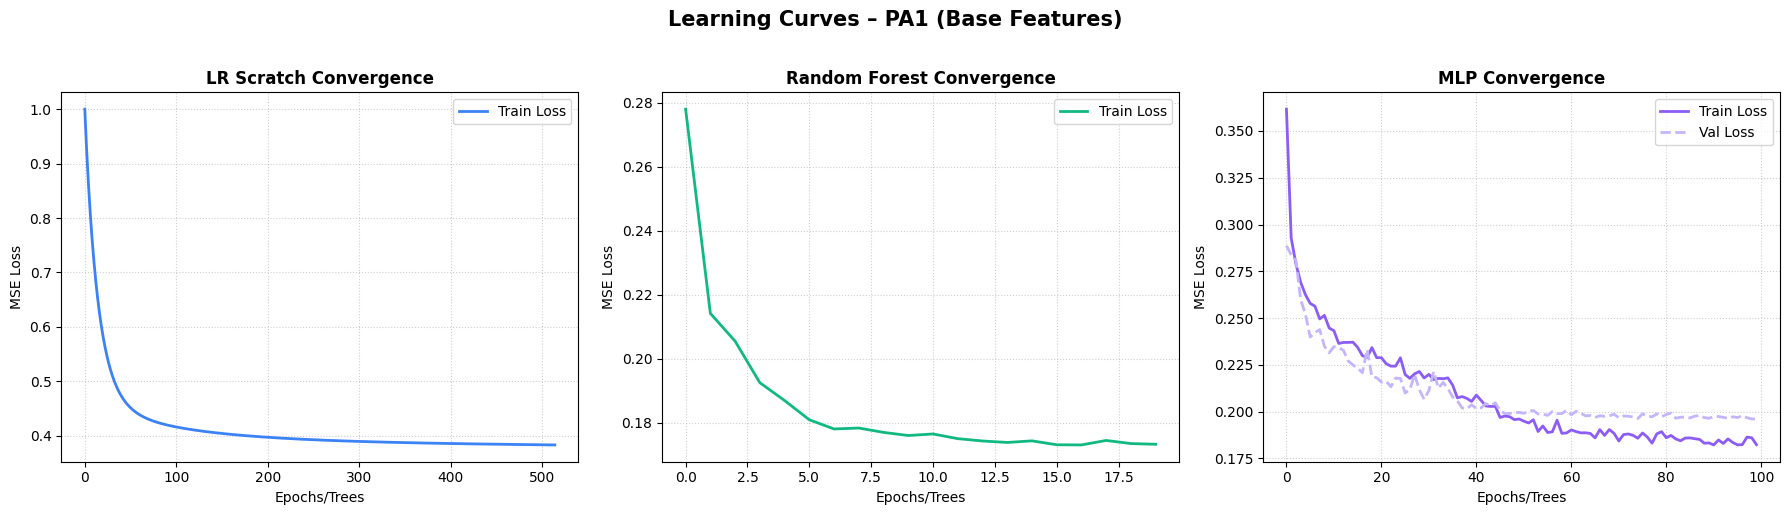

In [37]:
import matplotlib.pyplot as plt

# Find the best performing scenario dynamically based on the highest R2 score
best_scenario = df.loc[df['R2'].idxmax()]['Scenario']
print(f"Plotting learning curves for the best performing scenario: {best_scenario}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'Learning Curves – {best_scenario}', fontsize=15, fontweight='bold', y=1.02)

model_names = ['LR Scratch', 'Random Forest', 'MLP']
colors = [('#3B82F6', '#93C5FD'), ('#10B981', '#6EE7B7'), ('#8B5CF6', '#C4B5FD')]

for ax, mname, (c_main, c_sub) in zip(axes, model_names, colors):
    train_hist, val_hist = loss_store[(best_scenario, mname)]
    ax.plot(train_hist, label='Train Loss', color=c_main, linewidth=2)
    if val_hist is not None:
        ax.plot(val_hist, label='Val Loss', color=c_sub, linewidth=2, linestyle='--')
    ax.set_title(f'{mname} Convergence', fontsize=12, fontweight='bold')
    ax.set_xlabel('Epochs/Trees')
    ax.set_ylabel('MSE Loss')
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend()

plt.tight_layout()
plt.show()

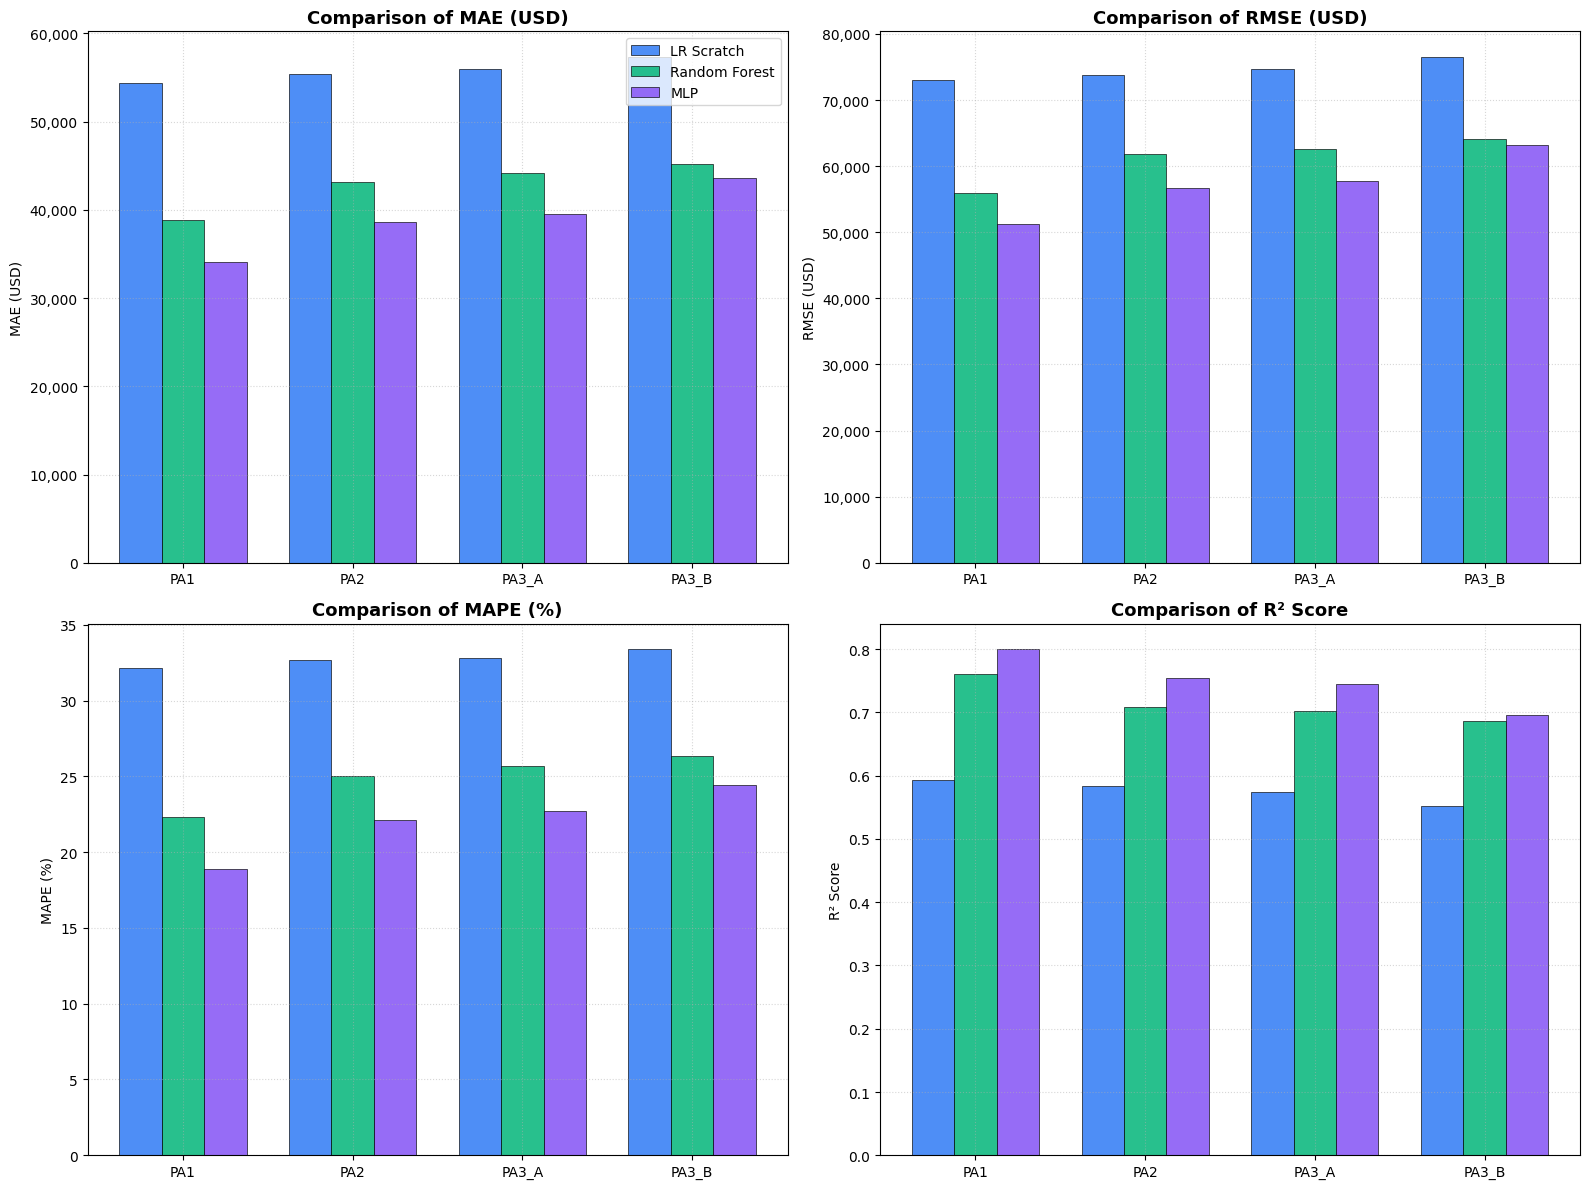

In [38]:
metrics_cols = ['MAE', 'RMSE', 'MAPE(%)', 'R2']
metric_labels = ['MAE (USD)', 'RMSE (USD)', 'MAPE (%)', 'R² Score']
model_order = ['LR Scratch', 'Random Forest', 'MLP']
sc_order = ['PA1 (Base Features)', 'PA2 (Reduced)', 'PA3_A (Mean Aggregation)', 'PA3_B (PCA Aggregation)']
bar_colors = ['#3B82F6', '#10B981', '#8B5CF6']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

x_indices = np.arange(len(sc_order))
bar_width = 0.25

for i, (m_col, label) in enumerate(zip(metrics_cols, metric_labels)):
    ax = axes[i]
    for j, m_name in enumerate(model_order):
        m_data = df[(df['Model'] == m_name)]
        # Reindex to match sc_order
        m_data = m_data.set_index('Scenario').reindex(sc_order).reset_index()
        vals = m_data[m_col].values
        
        ax.bar(x_indices + j * bar_width, vals, bar_width, label=m_name, color=bar_colors[j], alpha=0.9, edgecolor='black', linewidth=0.5)
    
    ax.set_title(f'Comparison of {label}', fontsize=13, fontweight='bold')
    ax.set_xticks(x_indices + bar_width)
    ax.set_xticklabels([s.split(' ')[0] for s in sc_order], fontsize=10)  # Short name for tick labels
    ax.set_ylabel(label)
    ax.grid(True, linestyle=':', alpha=0.5)
    if i == 0:
        ax.legend()
        
    # Format currency labels for y-axis on MAE/RMSE
    if m_col in ['MAE', 'RMSE']:
        ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

plt.tight_layout()
plt.show()

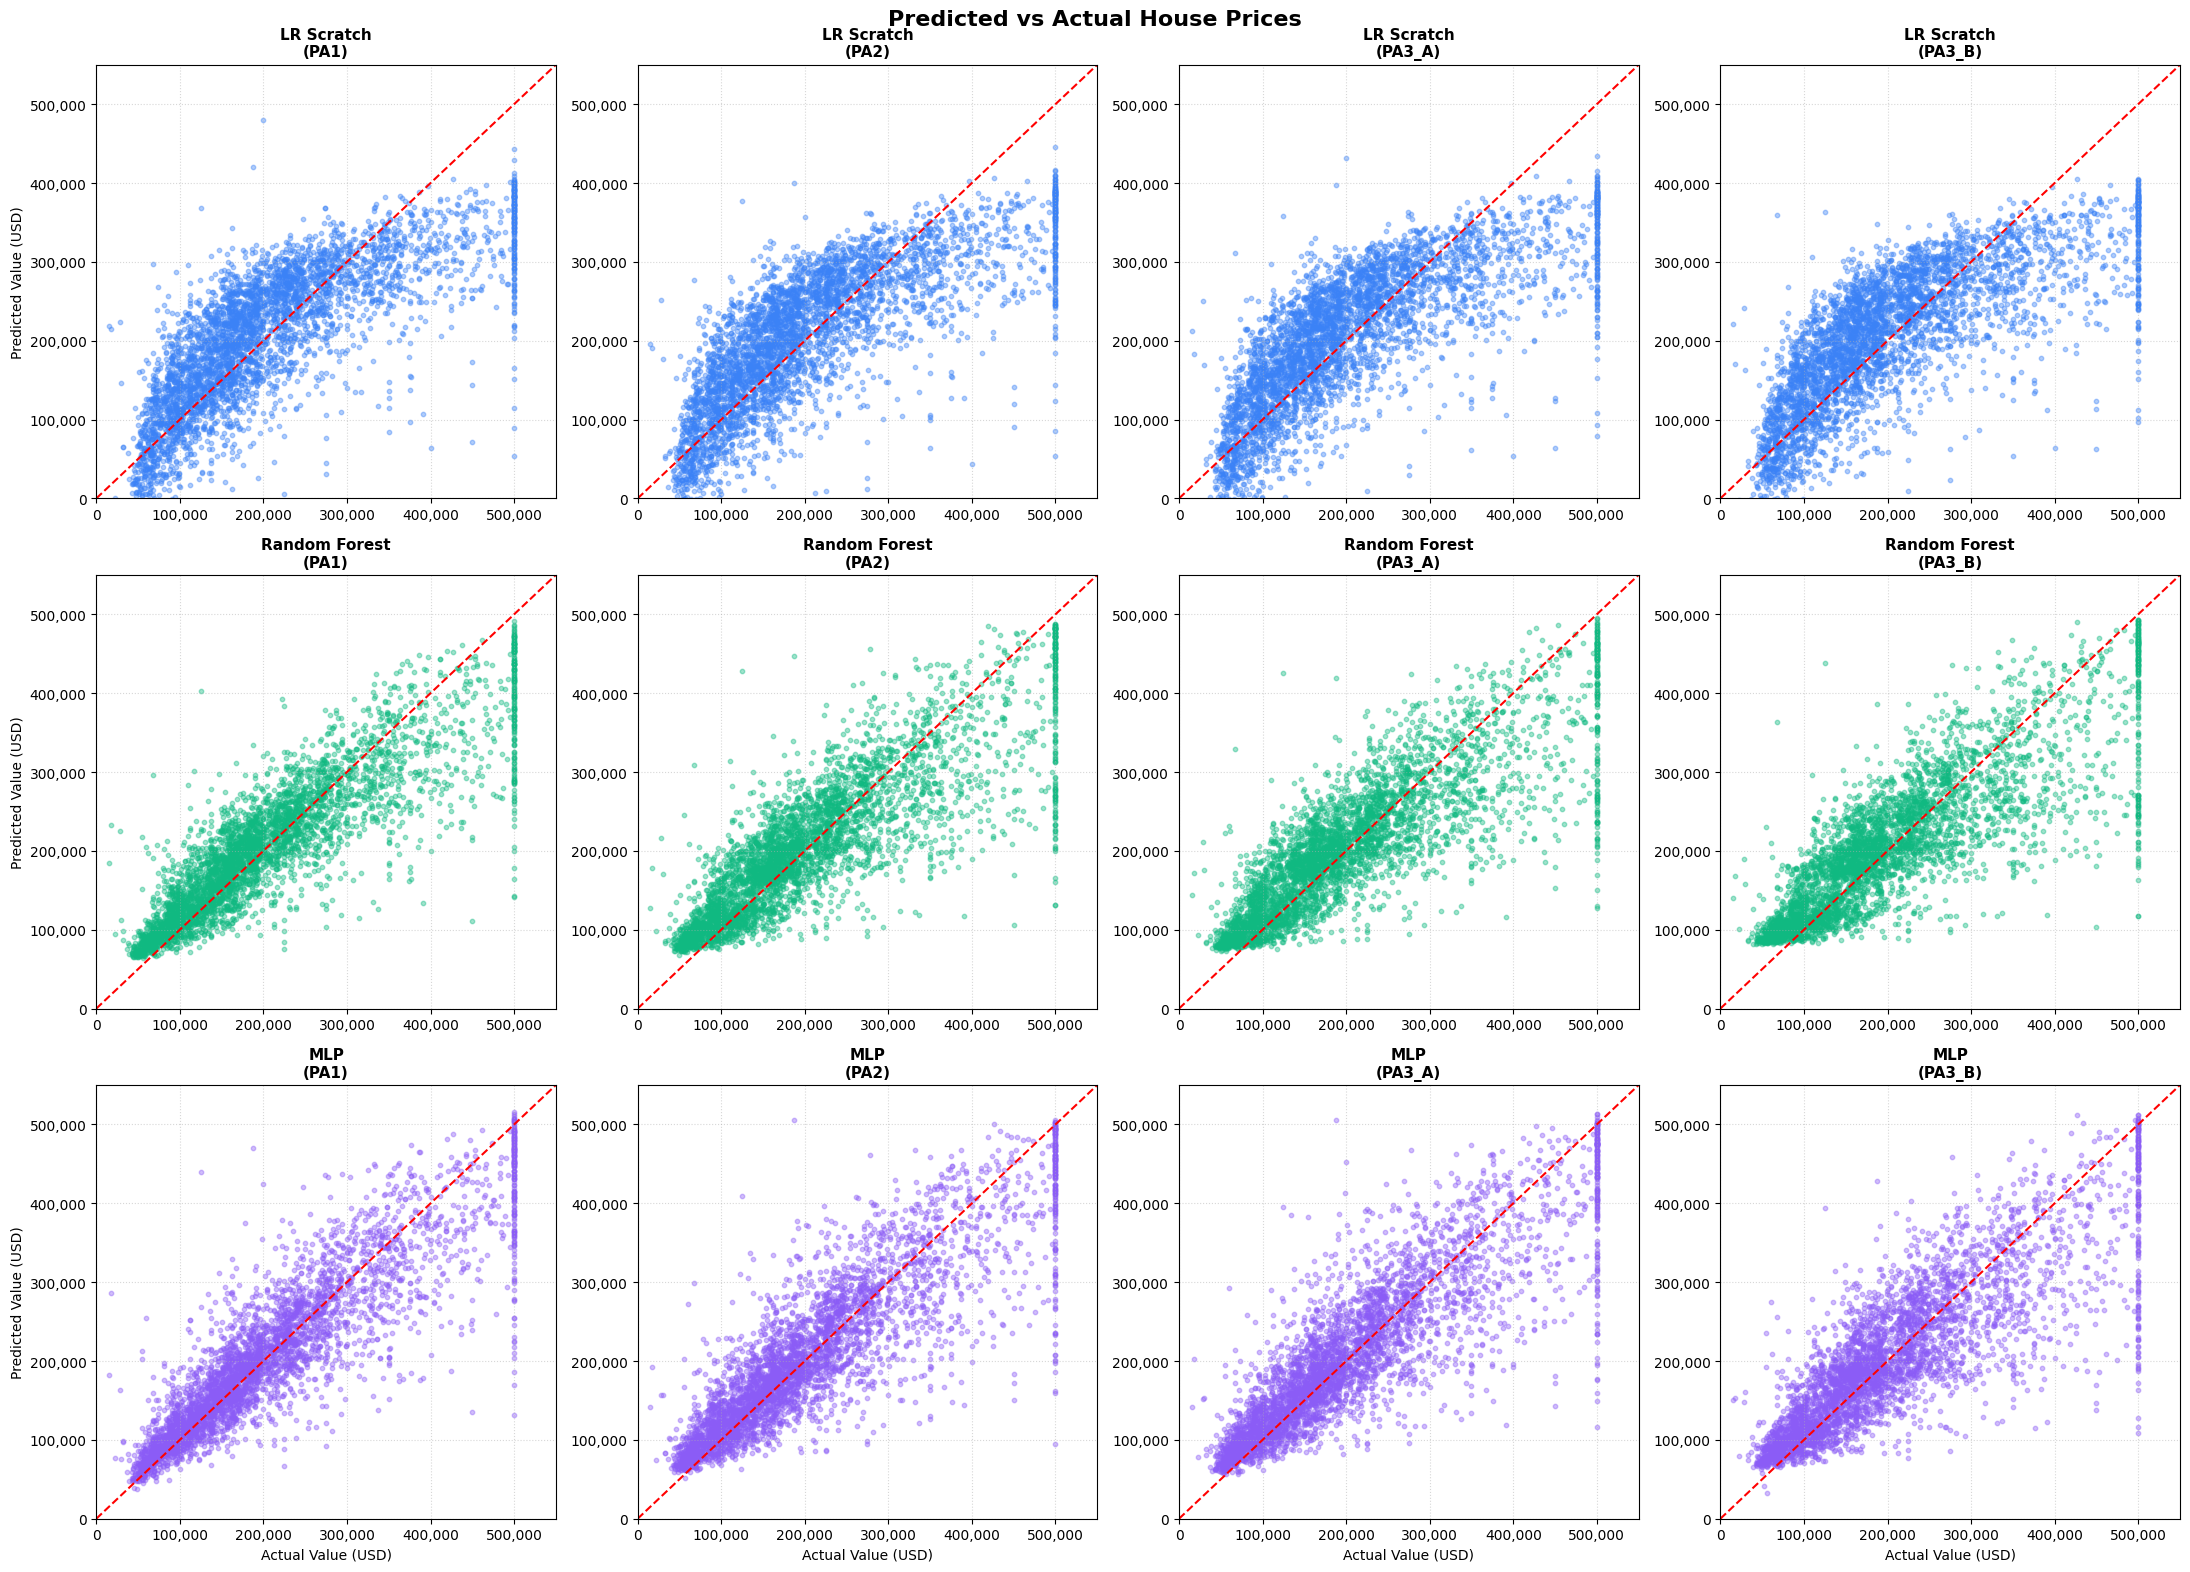

In [39]:
fig, axes = plt.subplots(3, 4, figsize=(22, 16))
fig.suptitle('Predicted vs Actual House Prices', fontsize=16, fontweight='bold')

scatter_colors = {'LR Scratch': '#3B82F6', 'Random Forest': '#10B981', 'MLP': '#8B5CF6'}
sc_order = ['PA1 (Base Features)', 'PA2 (Reduced)', 'PA3_A (Mean Aggregation)', 'PA3_B (PCA Aggregation)']
model_order = ['LR Scratch', 'Random Forest', 'MLP']

for row, mname in enumerate(model_order):
    for col, sc_name in enumerate(sc_order):
        ax = axes[row, col]
        y_pred = pred_store.get((sc_name, mname))
        
        if y_pred is not None:
            ax.scatter(y_test, y_pred, alpha=0.4, color=scatter_colors[mname], s=10)
            # Draw 45 degree reference line
            ax.plot([0, 550000], [0, 550000], color='red', linestyle='--', linewidth=1.5)
            
            # Set limits and format
            ax.set_xlim([0, 550000])
            ax.set_ylim([0, 550000])
            ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
            ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
            
            ax.set_title(f'{mname}\n({sc_name.split(" ")[0]})', fontsize=11, fontweight='bold')
            if row == 2:
                ax.set_xlabel('Actual Value (USD)')
            if col == 0:
                ax.set_ylabel('Predicted Value (USD)')
            ax.grid(True, linestyle=':', alpha=0.5)
        else:
            ax.text(0.5, 0.5, 'N/A', ha='center', va='center')

plt.tight_layout()
plt.show()

In [40]:
# Tạo bản sao để định dạng hiển thị đẹp mắt
display_df = df.copy()

# Định dạng các cột số tiền mặt (USD) với dấu phẩy phân tách hàng nghìn
display_df['MAE'] = display_df['MAE'].map('{:,.0f}'.format)
display_df['RMSE'] = display_df['RMSE'].map('{:,.0f}'.format)

# Định dạng các tỷ lệ phần trăm và R2 làm tròn số thập phân
display_df['MAPE(%)'] = display_df['MAPE(%)'].map('{:.2f}'.format)
display_df['R2'] = display_df['R2'].map('{:.4f}'.format)

# Định dạng thời gian chạy (mili-giây)
display_df['Train_ms'] = display_df['Train_ms'].map('{:.0f}'.format)
display_df['Inf_ms'] = display_df['Inf_ms'].map('{:.1f}'.format)

# Đổi tên các cột hiển thị cho chuyên nghiệp
display_df.columns = [
    'Scenario', 
    'Model', 
    'MAE (USD)', 
    'RMSE (USD)', 
    'MAPE (%)', 
    'R² Score', 
    'Train (ms)', 
    'Inf (ms)'
]

print('\n--- Final Scenario Comparison Results Table ---')
print(display_df.to_string(index=False))


--- Final Scenario Comparison Results Table ---
                Scenario         Model MAE (USD) RMSE (USD) MAPE (%) R² Score Train (ms) Inf (ms)
     PA1 (Base Features)    LR Scratch    54,428     73,041    32.16   0.5929        139      0.2
     PA1 (Base Features) Random Forest    38,837     55,906    22.32   0.7615      23177    193.2
     PA1 (Base Features)           MLP    34,110     51,193    18.87   0.8000      38678      1.1
           PA2 (Reduced)    LR Scratch    55,388     73,792    32.68   0.5845        128      0.3
           PA2 (Reduced) Random Forest    43,161     61,837    25.01   0.7082      19498    179.9
           PA2 (Reduced)           MLP    38,654     56,690    22.12   0.7547      38464      1.2
PA3_A (Mean Aggregation)    LR Scratch    55,948     74,713    32.81   0.5740        124      0.2
PA3_A (Mean Aggregation) Random Forest    44,123     62,535    25.67   0.7016      18391    178.0
PA3_A (Mean Aggregation)           MLP    39,556     57,743    22.68 